In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
import string
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords')
nltk.download('punkt')

%matplotlib inline
sns.set_theme(style="whitegrid")
print("All libraries loaded.")

All libraries loaded.


[nltk_data] Downloading package stopwords to /home/Aditya/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/Aditya/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
fake = pd.read_csv('../data/Fake.csv')
real = pd.read_csv('../data/True.csv')

fake['label'] = 1   # Fake = 1
real['label'] = 0   # Real = 0

df = pd.concat([fake, real], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (44898, 5)


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",1
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",0
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",0
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",1
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",0


In [3]:
print(df.info())
print("\n--- Missing Values ---")
print(df.isnull().sum())
print("\n--- Class Distribution ---")
print(df['label'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB
None

--- Missing Values ---
title      0
text       0
subject    0
date       0
label      0
dtype: int64

--- Class Distribution ---
label
1    23481
0    21417
Name: count, dtype: int64


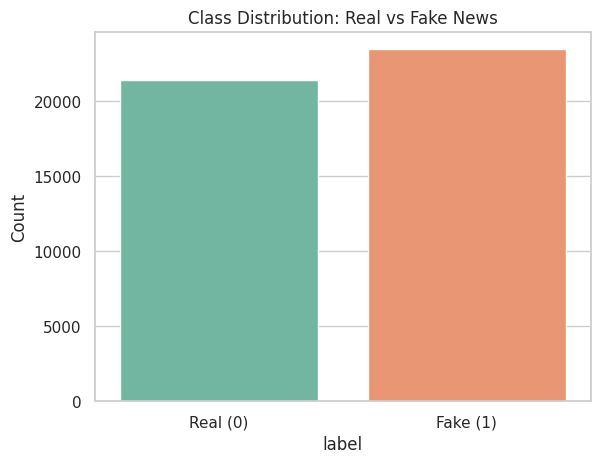

In [4]:
ax = sns.countplot(x='label', data=df, palette='Set2')
ax.set_xticklabels(['Real (0)', 'Fake (1)'])
plt.title('Class Distribution: Real vs Fake News')
plt.ylabel('Count')
plt.show()

       text_length  word_count
label                         
0      2383.278517  385.640099
1      2547.396235  423.197905


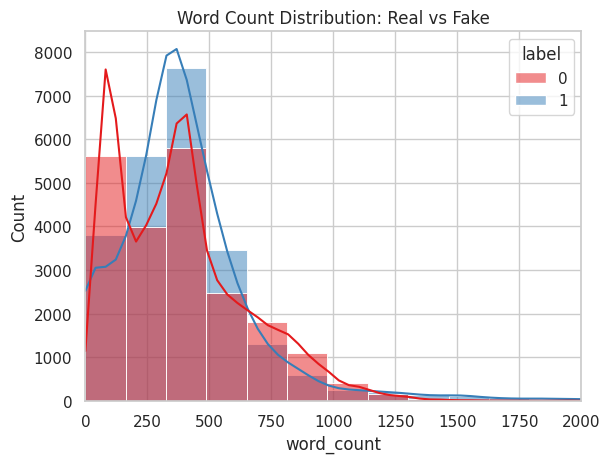

In [5]:
df['text_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

print(df.groupby('label')[['text_length', 'word_count']].mean())

sns.histplot(data=df, x='word_count', hue='label', bins=50, kde=True, palette='Set1')
plt.title('Word Count Distribution: Real vs Fake')
plt.xlim(0, 2000)
plt.show()

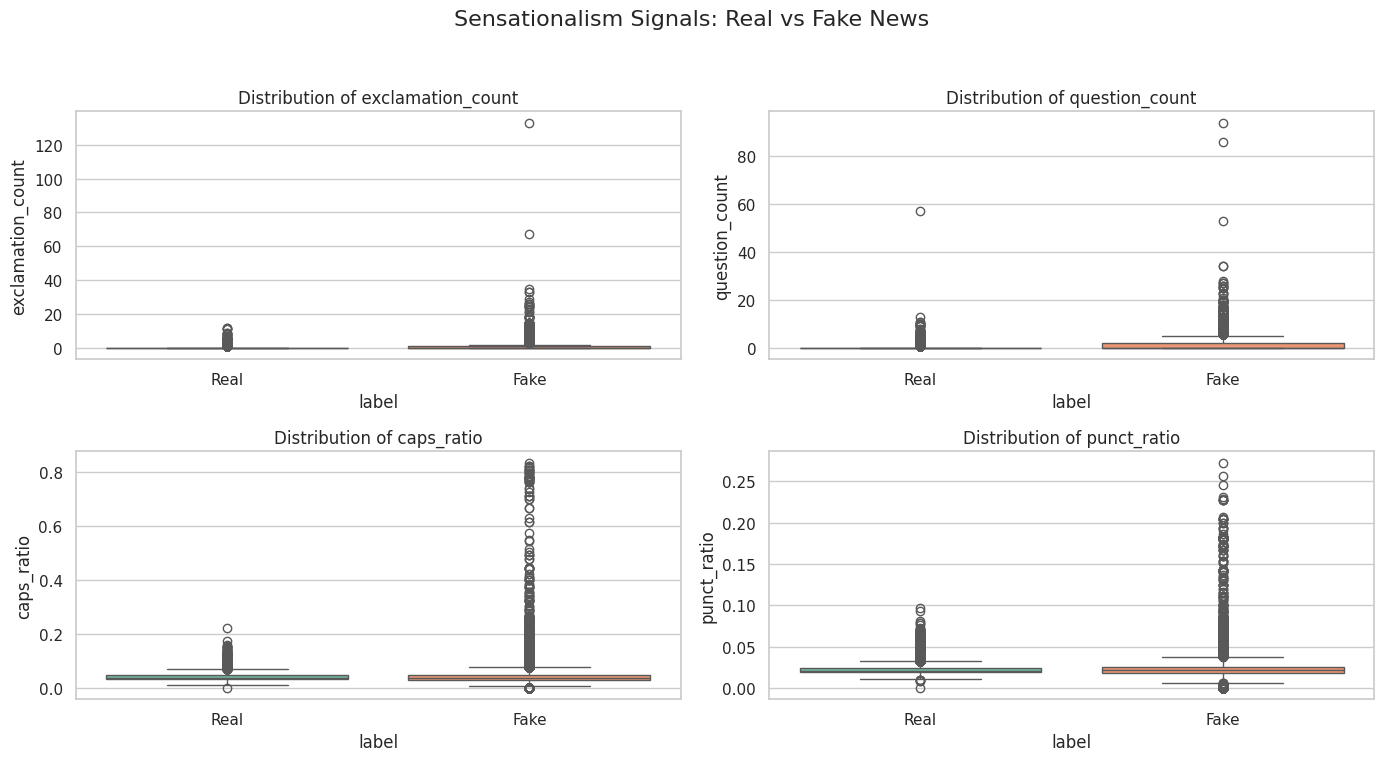

Kaggle base dataset saved → kaggle_only.csv
NOTE: Sensationalism features here are for EDA only.
NB2 will recompute them for ALL rows (Kaggle + LIAR) after merge.


In [6]:
# --- Sensationalism Feature Extraction ---
df['exclamation_count'] = df['text'].apply(lambda x: str(x).count('!'))
df['question_count'] = df['text'].apply(lambda x: str(x).count('?'))
df['caps_ratio'] = df['text'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / (len(str(x)) + 1)
)
df['punct_ratio'] = df['text'].apply(
    lambda x: sum(1 for c in str(x) if c in string.punctuation) / (len(str(x)) + 1)
)

# --- Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
cols = ['exclamation_count', 'question_count', 'caps_ratio', 'punct_ratio']

for ax, col in zip(axes.flatten(), cols):
    sns.boxplot(x='label', y=col, data=df, palette='Set2', ax=ax)
    ax.set_xticklabels(['Real', 'Fake'])
    ax.set_title(f'Distribution of {col}')

plt.suptitle('Sensationalism Signals: Real vs Fake News', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

df.to_csv('../data/kaggle_only.csv', index=False)
print("Kaggle base dataset saved → kaggle_only.csv")
print("NOTE: Sensationalism features here are for EDA only.")
print("NB2 will recompute them for ALL rows (Kaggle + LIAR) after merge.")

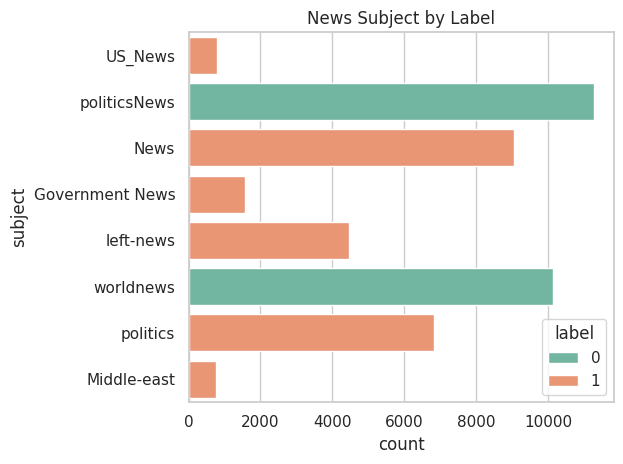

In [7]:
sns.countplot(y='subject', data=df, hue='label', palette='Set2')
plt.title('News Subject by Label')
plt.tight_layout()
plt.show()

In [8]:
# ── KAGGLE ONLY DATA ──
df.to_csv('../data/kaggle_only.csv', index=False)

print("Kaggle base dataset saved → kaggle_only.csv")
print("Do NOT rerun this after running NB2")
print(" labeled_data.csv saved to data/ folder")

Kaggle base dataset saved → kaggle_only.csv
Do NOT rerun this after running NB2
 labeled_data.csv saved to data/ folder


In [9]:
# ── KAGGLE ONLY DATA ──
df.to_csv('../data/kaggle_only.csv', index=False)

print("Kaggle base dataset saved → kaggle_only.csv")
print("Do NOT rerun this after running NB2")
print(" File saved with new columns!")

Kaggle base dataset saved → kaggle_only.csv
Do NOT rerun this after running NB2
 File saved with new columns!


In [10]:
import sys
print(sys.executable)

/home/Aditya/group10_fake_news/nlp_env/bin/python
